###### 2/17/2026
## Initial SARMIA model for Climate Data


#### Variable and Parameters Names
 - Climate = the original data set (146 observations with 19 parameters)
 - months = Monthly climate data
 - J.D = Jan - Dec (Yearly temp)
 - N.D = Dec - Nov (Meteorological Year)
 - DJF = Dec, Jan, Feb
 - MAM = Mar, Apr, May
 - JJA = June, July, Aug
 - SON = Sep, Oct, Nov




In [1]:
# Libraries to for use
# pmdarima = "py" + "arima" and seems to be a strong choice for Python?
## documentation: https://alkaline-ml.com/pmdarima/modules/classes.html
import pandas as pd
import numpy as np
from pmdarima.arima import ADFTest, ARIMA, AutoARIMA
from pmdarima.utils import as_series, acf, diff, pacf, plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit, train_test_split
#from statmodels import 
#from pmdarima.fit import summary, predict


## Cross Validation -- Rolling Origin CV with Profit Package

# Setting graph style:
plt.style.use('bmh')

#### Initial Loading and processing of data:

In [2]:
Climate = pd.read_csv("Data/Global means.csv")
Climate.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,***,***,-0.13,-0.17,-0.21
1,1881,-0.20,-0.15,0.03,0.04,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.15,0.13,0.04,-0.17,-0.15,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.12,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-0.11,-0.18,-0.2,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.41,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


In [5]:
for c in Climate.columns:
    count = (Climate[c] == '***').sum()
    print(f'Number of No Phone Service: {c}; {count}')
print("There appears to be only one missing value in D-N and DJF")

Number of No Phone Service: Year; 0
Number of No Phone Service: Jan; 0
Number of No Phone Service: Feb; 0
Number of No Phone Service: Mar; 0
Number of No Phone Service: Apr; 0
Number of No Phone Service: May; 0
Number of No Phone Service: Jun; 0
Number of No Phone Service: Jul; 0
Number of No Phone Service: Aug; 0
Number of No Phone Service: Sep; 0
Number of No Phone Service: Oct; 0
Number of No Phone Service: Nov; 0
Number of No Phone Service: Dec; 0
Number of No Phone Service: J-D; 0
Number of No Phone Service: D-N; 1
Number of No Phone Service: DJF; 1
Number of No Phone Service: MAM; 0
Number of No Phone Service: JJA; 0
Number of No Phone Service: SON; 0
There appears to be only one missing value in D-N and DJF


We have two missing values. They occur because Meteorological yearly means take data from December of the previous year through November of the current year. In these two places, the previous change in December anomaly is not included in the data set. 
Options: 
- A: Average the known values and place them into the missing values (I will use this one for now). 
- B: Find the anomaly value and calculate the correct value.   

In [3]:
## Cleaning Missing Values, by averaging over the data we have. 
labelsDJ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
labelsDJF = ['Jan', 'Feb']

Climate.at[0,"D-N"] = Climate.loc[0,labelsDJ].mean().round(2)
Climate.at[0,"DJF"] =  Climate.loc[0,labelsDJF].mean()

Climate.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,-0.18,-0.22,-0.13,-0.17,-0.21
1,1881,-0.20,-0.15,0.03,0.04,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.15,0.13,0.04,-0.17,-0.15,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.12,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.18,-0.17,-0.08,-0.07,-0.14,-0.21,-0.11,-0.23,-0.11,-0.18,-0.2,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.41,-0.34,-0.36,-0.30,-0.27,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


#### Initial SARIMA fitting
SARIMA models use a mix of AutoCorrelation and Moving Averages with integrated differencing. The first step is to test for stationarity and coerce the data to stationarity if needed. Then we use ACF and PACF (autocorrelation functions and partial autocorrelation functions) to decide the lag orders for the MA, AR, and seasonal MA and AR. 

In [4]:
#Pulling the J-D data
# Setting Time indexing for year as well. 
years = Climate["Year"].astype(int)

year = as_series(Climate["J-D"])
year.index = pd.to_datetime(
    [f"{y}-01"
     for y in years]
)

year.head()

## Fuller Dickey test for differencing
adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(year)
print(f"None Differenced data")
print(f"N used: {len(year)}")
print(f"P-value: {p_val:.6g}, Should difference: {should_diff}")
print("-------------------------------------------------------")

## Differencing and plotting ACF and PACF
test_year = diff(year)
adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(test_year)

print(f"Differenced Data")
print(f"N used: {len(year)}")
print(f"P-value: {p_val:.6g}, Should difference: {should_diff}")
# plot_acf(year)
# plot_pacf(year)

None Differenced data
N used: 146
P-value: 0.975569, Should difference: True
-------------------------------------------------------
Differenced Data
N used: 146
P-value: 0.01, Should difference: False


In [8]:
## Checking auto arima
model = AutoARIMA( # Note: p is the AR lags, q is the MA lags
    start_p=1, start_q=1, 
    max_p=3, max_q=3, # Defines the max q and p to test. 
    d=1, # To allow differencing
    seasonal=False,
    with_intercept=True,  # to allow drift constant
    stepwise=True,
    trace=True
)

model.fit(year)

print("Selected order:", model.model_.order)
print("AIC:", model.model_.aic())

## Suggests a (3,1,1)x(0,0,0)x0  (AR, Diff, MA) 
## (3,1,1) with drift AIC = -239.417

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-235.654, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-217.564, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-221.037, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-229.887, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-218.549, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-237.948, Time=0.42 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-233.109, Time=0.14 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-239.417, Time=0.61 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-238.599, Time=0.28 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-238.900, Time=0.85 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-235.975, Time=0.62 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-238.200, Time=0.27 sec

Best model:  ARIMA(3,1,1)(0,0,0)[0] intercept
Total fit time: 4.198 seconds
Selected order: (3, 1, 1)
AIC: -239.41749888810352


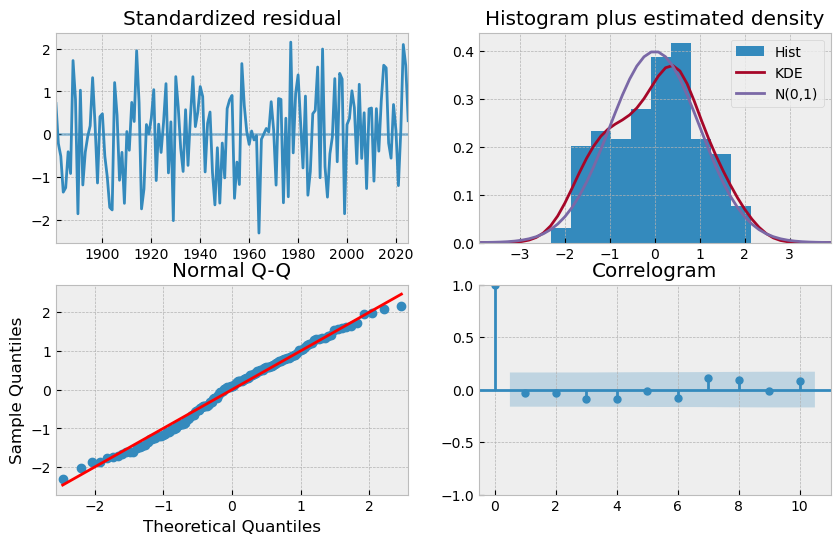

In [9]:
model.model_.plot_diagnostics(figsize=(10, 6)); 

In [5]:
## ARIMA model setting using (2,1,2) with drift
year = as_series(Climate["J-D"]) ## Resetting the data to avoid double differencing. ARIMA automatically differences
                                 ## if the I term is set to one. 
model_year = ARIMA(order=(3, 1, 1), 
              with_intercept=True, 
              suppress_warnings=True)

model_year.fit(year)
print(model_year.summary())

NameError: name 'model' is not defined

#### Initial SARIMA fitting for monthly data
The following is working with the full monthly data. Keep in mind that for time series data, the yearly J.D. data is not much different from running a 12 month smothing curve over each year. 

In [6]:
#Pulling the monthly data
years = Climate["Year"].astype(int)

month_df = Climate[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']]

months = month_df.stack()
months.index = pd.to_datetime(
    [f"{y}-{m:02d}-01"
     for y in years
     for m in range(1,13)]
)


months = pd.to_numeric(months, errors='coerce').dropna()
months.head()

1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.10
1880-04-01   -0.17
1880-05-01   -0.11
dtype: float64

In [12]:
## Fuller Dickey test for differencing
adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(months)
print(f"P-value: {p_val}, Should difference: {should_diff}") 
# plot_acf(months) This plot definitely still needs differencing. 
# plot_pacf(months)

P-value: 0.01, Should difference: False


In [ ]:
## Checking auto arima
model = AutoARIMA( # Note: p is the AR lags, q is the MA lags
    start_p=1, start_q=1, 
    max_p=2, max_q=2, # Defines the max q and p to test. 
    # d=1, # To allow diffencting
    seasonal=True,
    m = 12, # set for four month seasonal data. 
    start_P = 0, start_Q = 0,
    max_P = 2, max_Q = 2,
    with_intercept=True,  # to allow drift constant is likely not needed if seasonality is being used. 
    stepwise=True,
    trace=True
)

model_test = model.fit(months) ## suggesting a ARIMA(2,1,1)(1,0,1)[4] model

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 1752
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                1383.240
Date:                            Thu, 26 Feb 2026   AIC                          -2752.480
Time:                                    14:55:52   BIC                          -2714.253
Sample:                                01-01-1880   HQIC                         -2738.344
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   8.473e-06   3.21e-05      0.264      0.792   -5.45e-05    7.14e-05
ar.L1          0.2838      0.045   

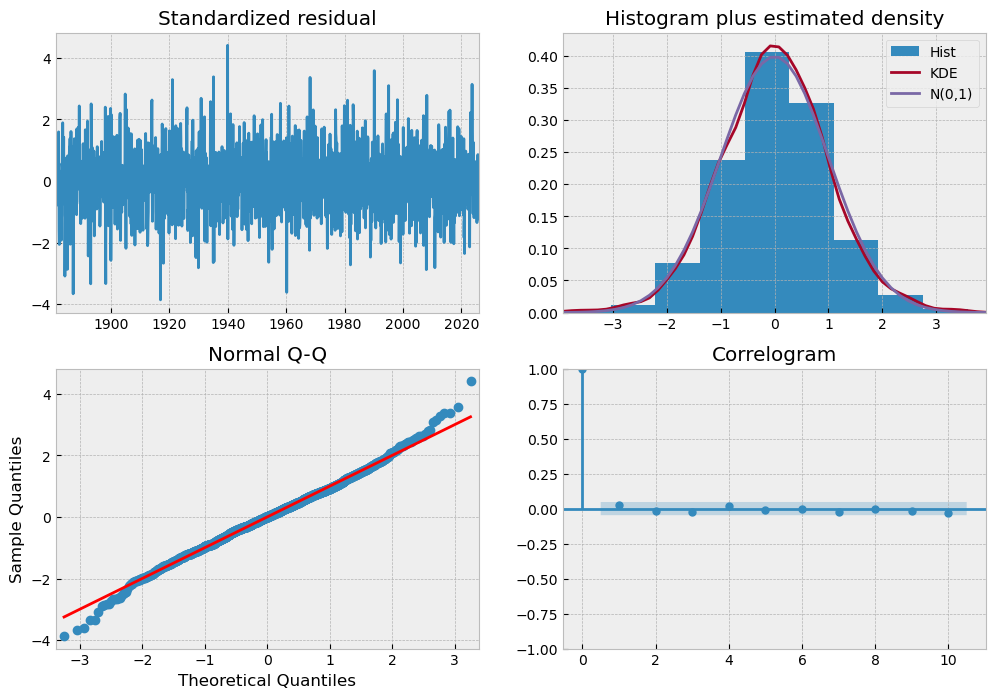

In [7]:
## ARIMA model setting using (2,1,1) with drift
model_month = ARIMA(order=(2, 1, 1), 
              seasonal_order=(1, 1, 1, 12), # (P, D, Q, s) - Changed to D=1 instead of D=0, think this should have seasonal differencing(?)
              with_intercept=True, 
              suppress_warnings=True)

model_month.fit(months)
print(model_month.summary())
model_month.plot_diagnostics(figsize=(12, 8));
# quarterly has a lowish Ljung-Box score, while monthly has a very nice score. Neither are significant so both should be valid models. 

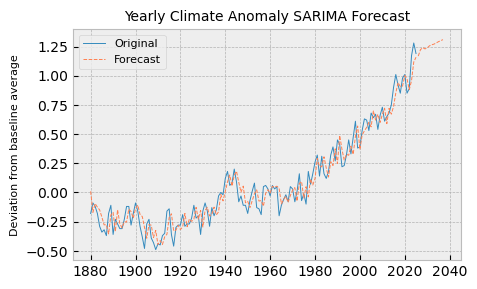

[[0.96903066 1.3668625 ]
 [0.97379097 1.47235979]
 [0.97377908 1.50741792]
 [0.94451968 1.51443303]
 [0.91875926 1.55669626]
 [0.91594773 1.59576397]
 [0.9044378  1.62496392]
 [0.89241874 1.64823124]
 [0.88111622 1.67956473]
 [0.87552777 1.70678347]
 [0.86648034 1.73366886]
 [0.85982825 1.7577952 ]]


In [25]:
## Visualizing the time series data and models for yearly data. 
forecast, conf = model_year.predict(n_periods = 12, return_conf_int = True)
fit = model_year.predict_in_sample(typ='levels')

plt.figure(figsize = (5,3))
plt.plot(as_series(Climate["J-D"]), linewidth = .7, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = .7, color = "coral", label = "Forecast")
#plt.fill_between(range(year.index[-1].year, year.index[-1].year + 12), conf[:,0], conf[:,1], color = 'skyblue')
plt.plot(fit, linestyle = "--", linewidth = .7, color = "coral")
plt.title("Yearly Climate Anomaly SARIMA Forecast", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.legend(fontsize = 8)
plt.show()
#print(conf)

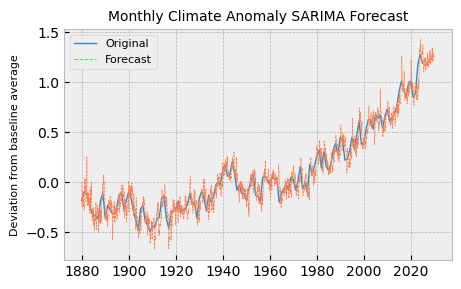

In [95]:
## Visualizing the time series data and models for yearly data.
forecast, conf = model_month.predict(n_periods = 48, return_conf_int = True)
fit = model_month.predict_in_sample(typ='levels')

plt.figure(figsize = (5,3))
plt.plot(as_series(Climate["J-D"]), linewidth = 1, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = .7, color = "coral", label = "Forecast")
#plt.fill_between(range(year.index[-1].year, year.index[-1].year + 12), conf[:,0], conf[:,1], color = 'skyblue')
plt.plot(fit, linestyle = "--", linewidth = .5, color = "coral")
plt.title("Monthly Climate Anomaly SARIMA Forecast", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.legend(fontsize = 8)
plt.show()
#print(conf)

### Setting the SARIMA to a testing/training to pull out an MSE value for comparison. 

In [10]:
## MSE Testing by reserving the last 20 years as testing data:
y = Climate['J-D']
X = Climate[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov','Dec']]


split = TimeSeriesSplit(n_splits = 2, test_size = 12)

for i, (train_index, test_index) in enumerate(split.split(X)):
    X_train = X.iloc[train_index,:]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index,:]
    y_test = y.iloc[test_index]

    
model_year_train = ARIMA(order=(3, 1, 1), 
              with_intercept=True, 
              suppress_warnings=True)

model_month_train = ARIMA(order=(2, 1, 1), 
              seasonal_order=(1, 1, 1, 12),
              with_intercept=True, 
              suppress_warnings=True)

model_year_train.fit(y_train);
model_month_train.fit(X_train.stack());

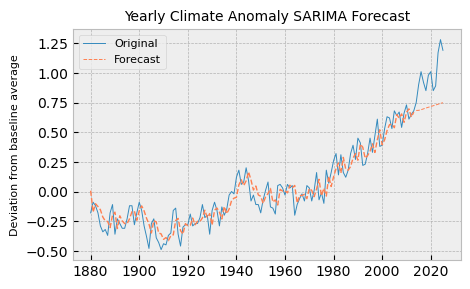

Mean Squared Error: 0.0916
Mean Absolute Error: 0.2699


In [39]:
forecast, conf = model_year_train.predict(n_periods = 12, return_conf_int = True)
fit = model_year_train.predict_in_sample(typ='levels')
mse = np.mean((forecast.values - y_test)**2)
mae = np.mean(abs(forecast.values - y_test))

plt.figure(figsize = (5,3))
plt.plot(as_series(Climate["J-D"]), linewidth = .7, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = .7, color = "coral", label = "Forecast")
#plt.fill_between(range(year.index[-1].year, year.index[-1].year + 12), conf[:,0], conf[:,1], color = 'skyblue')
plt.plot(fit, linestyle = "--", linewidth = 1, color = "coral")
plt.title("Yearly Climate Anomaly SARIMA Forecast", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.legend(fontsize = 8)
plt.show()

print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')

C:\Users\dustin.smith\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\dustin.smith\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


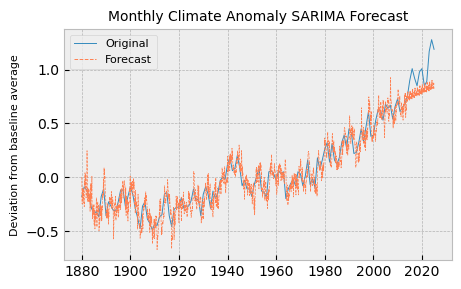

Mean Squared Error: 0.0523
Mean Absolute Error: 0.1894


In [38]:
forecast, conf = model_month_train.predict(n_periods = 144, return_conf_int = True)
forecast.index = pd.date_range(start="2013-01-01", periods=len(forecast), freq='MS')
fit = model_month_train.predict_in_sample(typ='levels')
fit.index = pd.date_range(start="1880-01-01", periods=len(fit), freq='MS')
mean_forecast = np.mean(forecast.values.reshape(12, 12), axis=1)
mse = np.mean((mean_forecast - y_test)**2)
mae = np.mean(abs(mean_forecast - y_test))

plt.figure(figsize = (5,3))
plt.plot((Climate["J-D"]), linewidth = .7, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = .7, color = "coral", label = "Forecast")
#plt.fill_between(range(year.index[-1].year, year.index[-1].year + 12), conf[:,0], conf[:,1], color = 'skyblue')
plt.plot(fit, linestyle = "--", linewidth = .5, color = "coral")
plt.title("Monthly Climate Anomaly SARIMA Forecast", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.legend(fontsize = 8)
plt.show()
#print(y_monthly)
#print(fit)
print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')

In [17]:
print(1608 - 1619)

-11


In [18]:
len(Climate["J-D"]) - 11

146